## Import & Load Model

In [1]:
# 1. Import Library
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 2. Tentukan lokasi Model V3 dan Foto yang ingin dites
MODEL_PATH = r"D:\best-model-v3-card-condition.pt"

# 3. Memuat Model
print("[*] Memuat Model V3 Lokal...")
model_v3 = YOLO(MODEL_PATH)
print("[✓] Model berhasil dimuat!")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Tigro\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
[*] Memuat Model V3 Lokal...
[✓] Model berhasil dimuat!


## Prediksi & Visualisasi

[*] Menganalisis Tampak Depan (Front)...
=== HASIL DETEKSI: TAMPAK DEPAN (FRONT) ===
- Terdeteksi: Card            (Confidence: 77.1%)

[*] Menganalisis Tampak Belakang (Back)...
=== HASIL DETEKSI: TAMPAK BELAKANG (BACK) ===
- Terdeteksi: Card            (Confidence: 93.3%)
- Terdeteksi: Corner Wear     (Confidence: 50.0%)
- Terdeteksi: Corner Wear     (Confidence: 47.0%)
- Terdeteksi: Corner Wear     (Confidence: 38.0%)
- Terdeteksi: Corner Wear     (Confidence: 37.4%)



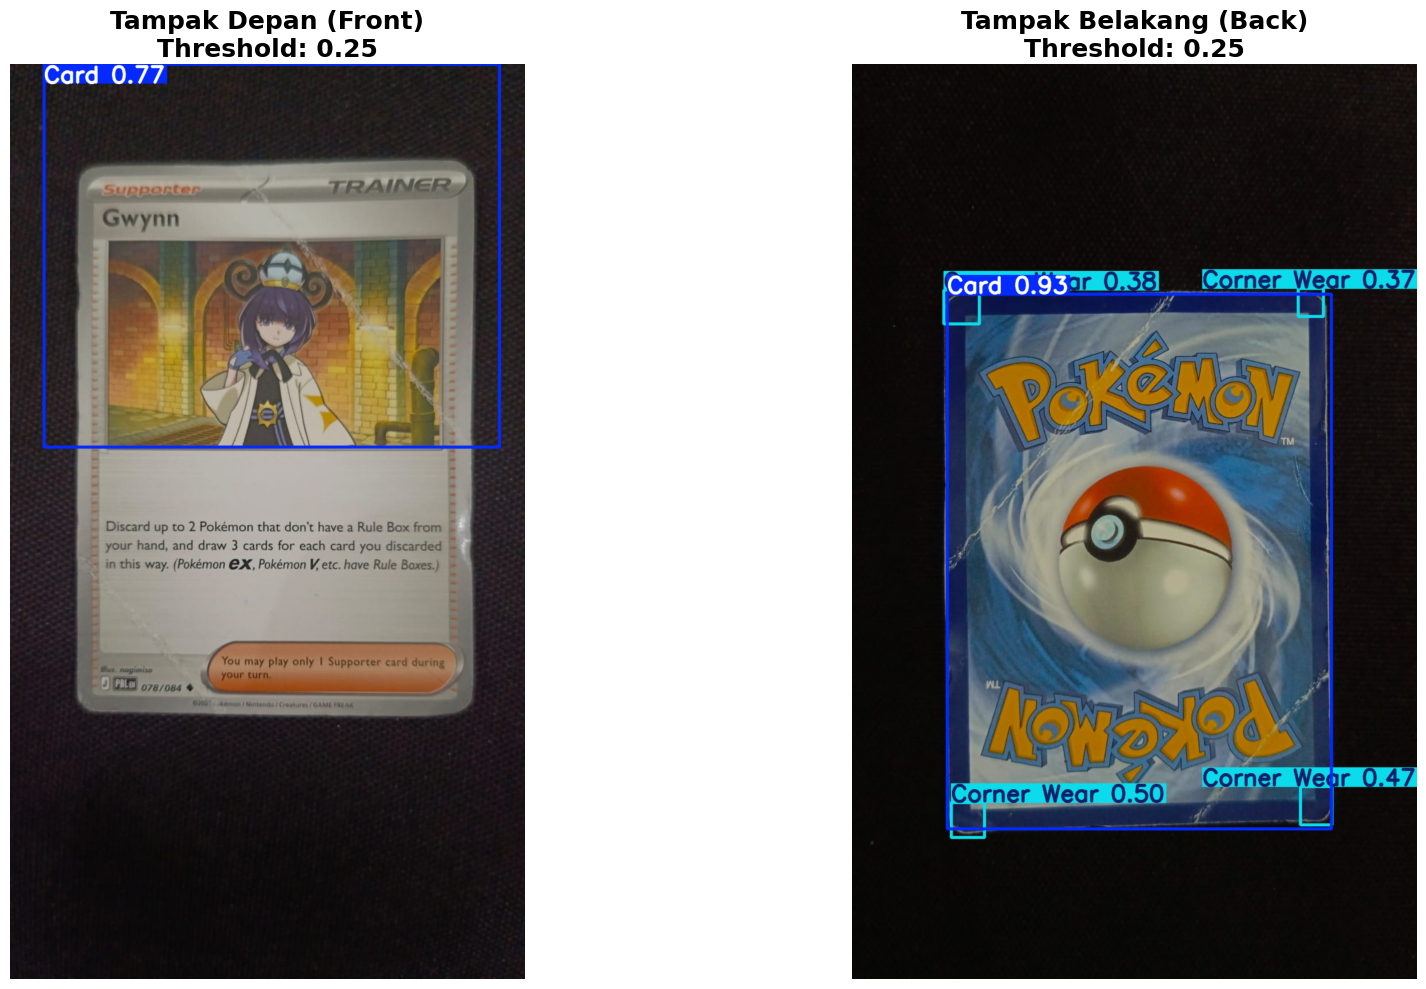

In [2]:
# 1. Daftar gambar yang akan diuji
images_to_test = [
    r"D:\Datasets\defect-card-front.jpeg",
    r"D:\Datasets\defect-card-back.jpeg"
]

# Siapkan kanvas gambar (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 2. Proses masing-masing gambar
for i, img_path in enumerate(images_to_test):
    # Penamaan judul otomatis
    title = "Tampak Depan (Front)" if "front" in img_path.lower() else "Tampak Belakang (Back)"
    print(f"[*] Menganalisis {title}...")
    
    # Inferensi V3 (Threshold 0.25)
    results = model_v3.predict(source=img_path, conf=0.25, verbose=False)
    
    # Render kotak dan konversi warna
    img_bgr = results[0].plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Tampilkan ke grafik
    axes[i].imshow(img_rgb)
    axes[i].axis('off')
    axes[i].set_title(f"{title}\nThreshold: 0.25", fontsize=18, fontweight="bold")
    
    # Cetak log detail deteksi di terminal bawah
    print(f"=== HASIL DETEKSI: {title.upper()} ===")
    if len(results[0].boxes) == 0:
        print("- Bersih (Tidak terdeteksi cacat / kartu)\n")
    else:
        for box in results[0].boxes:
            cls_id = int(box.cls[0].item())
            class_name = model_v3.names[cls_id]
            conf = box.conf[0].item()
            print(f"- Terdeteksi: {class_name:<15} (Confidence: {conf*100:.1f}%)")
        print() # spasi antar log

# 3. Tampilkan hasil akhir
plt.tight_layout()
plt.show()